In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from scipy.cluster.hierarchy import linkage
from scipy.spatial.distance import squareform

sns.set_theme(style="white")  # opzionale, solo estetica base

# ----------------------------
# 1) Dataset numerico per correlazioni (sensato: blocchi correlati)
# ----------------------------
def make_correlated_df(n=220, seed=0):
    rng = np.random.default_rng(seed)
    f1 = rng.normal(size=n)
    f2 = rng.normal(size=n)
    eps = lambda s=0.6: rng.normal(scale=s, size=n)

    return pd.DataFrame({
        "A":  1.0*f1 + eps(0.6),
        "B":  0.8*f1 + eps(0.7),
        "C": -0.7*f1 + eps(0.6),
        "D":  1.0*f2 + eps(0.6),
        "E":  0.9*f2 + eps(0.7),
        "F":  0.5*f1 + 0.5*f2 + eps(0.6),
        "G":  eps(1.0),
        "H":  0.3*f1 - 0.6*f2 + eps(0.7),
    })

df = make_correlated_df()

# ----------------------------
# 2) Corr + matrice p-value (Pearson)
# ----------------------------
def corr_pvals_pearson(df_num: pd.DataFrame):
    cols = df_num.columns
    n = len(cols)
    corr = pd.DataFrame(np.eye(n), index=cols, columns=cols, dtype=float)
    pval = pd.DataFrame(np.full((n, n), np.nan), index=cols, columns=cols, dtype=float)

    for i in range(n):
        for j in range(i+1, n):
            r, p = stats.pearsonr(df_num.iloc[:, i], df_num.iloc[:, j])
            corr.iat[i, j] = corr.iat[j, i] = r
            pval.iat[i, j] = pval.iat[j, i] = p

    return corr, pval

corr, pvals = corr_pvals_pearson(df)

# ----------------------------
# 3) Helper: stelle da p-value
# ----------------------------
def p_to_stars(p):
    if np.isnan(p): return ""
    if p <= 0.001: return "***"
    if p <= 0.01:  return "**"
    if p <= 0.05:  return "*"
    return ""

# mask triangolare (nascondo triangolo superiore + diagonale)
mask_upper = np.triu(np.ones_like(corr, dtype=bool))

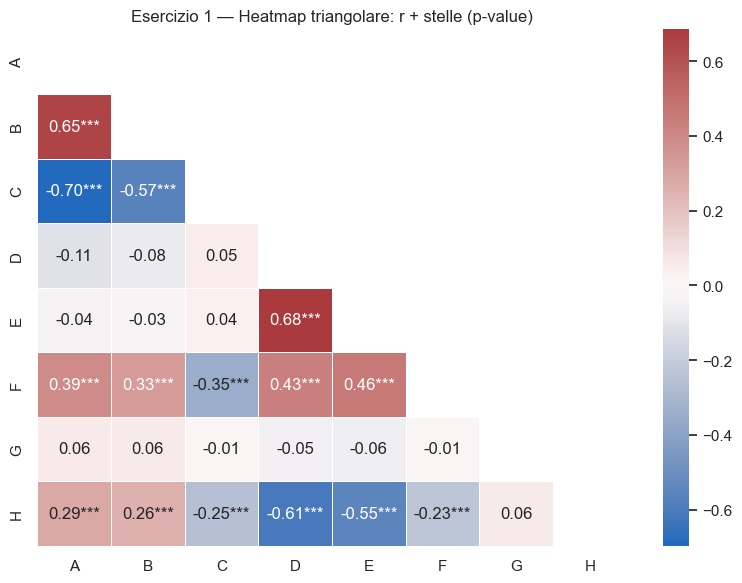

In [2]:
# ----------------------------
# ESERCIZIO 1
# ----------------------------

# annotazione combinata: r + stelle
annot = np.empty_like(corr.values, dtype=object)
for i in range(corr.shape[0]):
    for j in range(corr.shape[1]):
        annot[i, j] = f"{corr.values[i, j]:.2f}{p_to_stars(pvals.values[i, j])}"

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr,
    mask=mask_upper,
    annot=annot,
    fmt="",
    center=0,
    cmap="vlag",
    linewidths=0.5
)
plt.title("Esercizio 1 — Heatmap triangolare: r + stelle (p-value)")
plt.tight_layout()
plt.show()

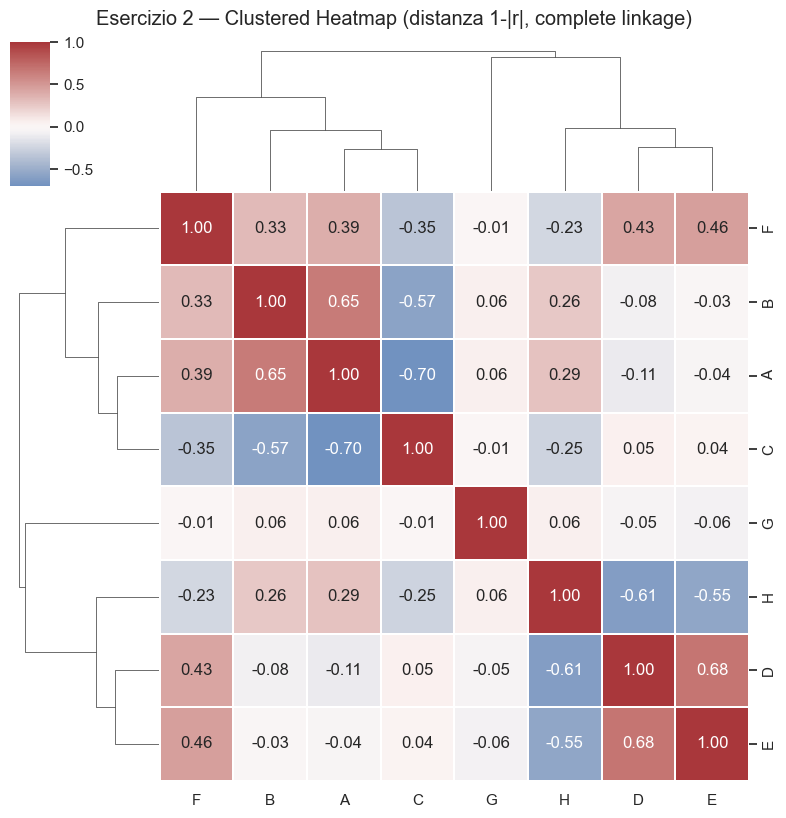

In [3]:
# ----------------------------
# ESERCIZIO 2
# ----------------------------

# distanza: 1 - |corr| (forti negative contano come "simili")
dist = 1 - np.abs(corr.values)
np.fill_diagonal(dist, 0.0)

# linkage su matrice di distanza (serve forma "condensed")
Z = linkage(squareform(dist, checks=False), method="complete")

# clustermap sulla matrice corr, ma forzando il clustering con i linkage calcolati
g = sns.clustermap(
    corr,
    row_linkage=Z,
    col_linkage=Z,
    cmap="vlag",
    center=0,
    annot=True,
    fmt=".2f",
    linewidths=0.3,
    figsize=(8, 8)
)
g.fig.suptitle("Esercizio 2 — Clustered Heatmap (distanza 1-|r|, complete linkage)", y=1.02)
plt.show()

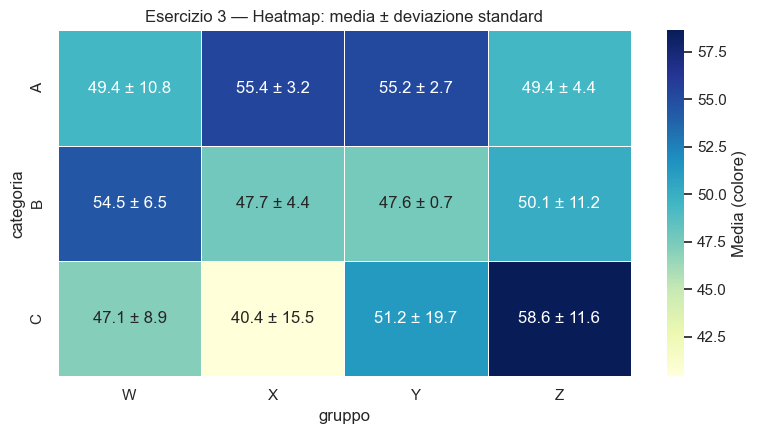

In [4]:
# ----------------------------
# ESERCIZIO 3
# ----------------------------

rng = np.random.default_rng(1)
data = pd.DataFrame({
    "categoria": np.repeat(["A", "B", "C"], 12),
    "gruppo": np.tile(["X", "Y", "Z", "W"], 9),
    "valore": rng.normal(loc=50, scale=10, size=36),
})

pivot = data.pivot_table(
    values="valore",
    index="categoria",
    columns="gruppo",
    aggfunc=["mean", "std"]
)

mean_mat = pivot["mean"]
std_mat  = pivot["std"]

# annotazione: "mean ± sd"
annot = np.empty(mean_mat.shape, dtype=object)
for i in range(mean_mat.shape[0]):
    for j in range(mean_mat.shape[1]):
        annot[i, j] = f"{mean_mat.values[i, j]:.1f} ± {std_mat.values[i, j]:.1f}"

plt.figure(figsize=(8, 4.5))
sns.heatmap(
    mean_mat,
    annot=annot,
    fmt="",
    cmap="YlGnBu",
    linewidths=0.5,
    cbar_kws={"label": "Media (colore)"}
)
plt.title("Esercizio 3 — Heatmap: media ± deviazione standard")
plt.tight_layout()
plt.show()

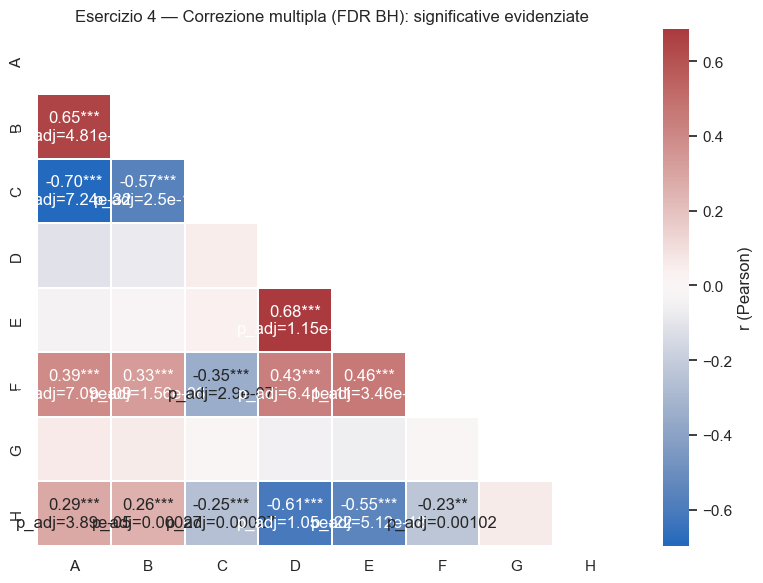

In [5]:
# ----------------------------
# ESERCIZIO 4
# ----------------------------

# 1) prendo solo i p-value unici (triangolo inferiore senza diagonale)
n = corr.shape[0]
tri_i, tri_j = np.tril_indices(n, k=-1)
flat_p = pvals.values[tri_i, tri_j]

# 2) correzione multipla: FDR (Benjamini-Hochberg) come da slide
try:
    from statsmodels.stats.multitest import multipletests
    rej, p_corr, _, _ = multipletests(flat_p, alpha=0.05, method="fdr_bh")
except Exception:
    # fallback: BH manuale
    p = np.asarray(flat_p, dtype=float)
    m = p.size
    order = np.argsort(p)
    p_sorted = p[order]
    ranks = np.arange(1, m+1)

    p_adj_sorted = p_sorted * m / ranks
    p_adj_sorted = np.minimum.accumulate(p_adj_sorted[::-1])[::-1]
    p_adj_sorted = np.clip(p_adj_sorted, 0, 1)

    rej_sorted = p_sorted <= (0.05 * ranks / m)

    p_corr = np.empty_like(p_adj_sorted)
    rej = np.empty_like(rej_sorted, dtype=bool)
    p_corr[order] = p_adj_sorted
    rej[order] = rej_sorted

# 3) ricostruisco matrici p_adj e reject (simmetriche)
p_adj = np.full((n, n), np.nan, dtype=float)
sig   = np.zeros((n, n), dtype=bool)

p_adj[tri_i, tri_j] = p_corr
p_adj[tri_j, tri_i] = p_corr
sig[tri_i, tri_j]   = rej
sig[tri_j, tri_i]   = rej

# 4) preparo annotazioni: r + stelle su p_adj + p_adj
annot = np.empty((n, n), dtype=object)
for i in range(n):
    for j in range(n):
        if np.isnan(p_adj[i, j]):
            annot[i, j] = f"{corr.values[i, j]:.2f}"
        else:
            annot[i, j] = f"{corr.values[i, j]:.2f}{p_to_stars(p_adj[i, j])}\np_adj={p_adj[i, j]:.3g}"

# 5) plotting: base (tutto triangolo inferiore) “sbiadito” + overlay significativo “pieno”
plt.figure(figsize=(8, 6))

# base: tutte le celle visibili (ma senza pretese: leggibilità)
ax = sns.heatmap(
    corr,
    mask=mask_upper,
    annot=False,
    center=0,
    cmap="vlag",
    linewidths=0.5,
    cbar_kws={"label": "r (Pearson)"}
)
plt.title("Esercizio 4 — Correzione multipla (FDR BH): significative evidenziate")

# overlay: mostro SOLO le celle significative nel triangolo inferiore
mask_overlay = mask_upper | (~sig)  # nascondo tutto ciò che non è significativo
sns.heatmap(
    corr,
    mask=mask_overlay,
    annot=annot,
    fmt="",
    center=0,
    cmap="vlag",
    linewidths=1.4,   # bordo più evidente sui significativi
    cbar=False,
    ax=ax
)

plt.tight_layout()
plt.show()

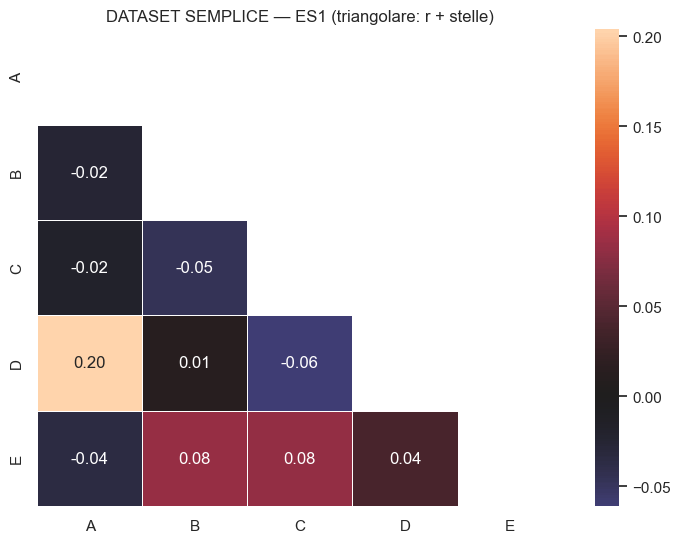

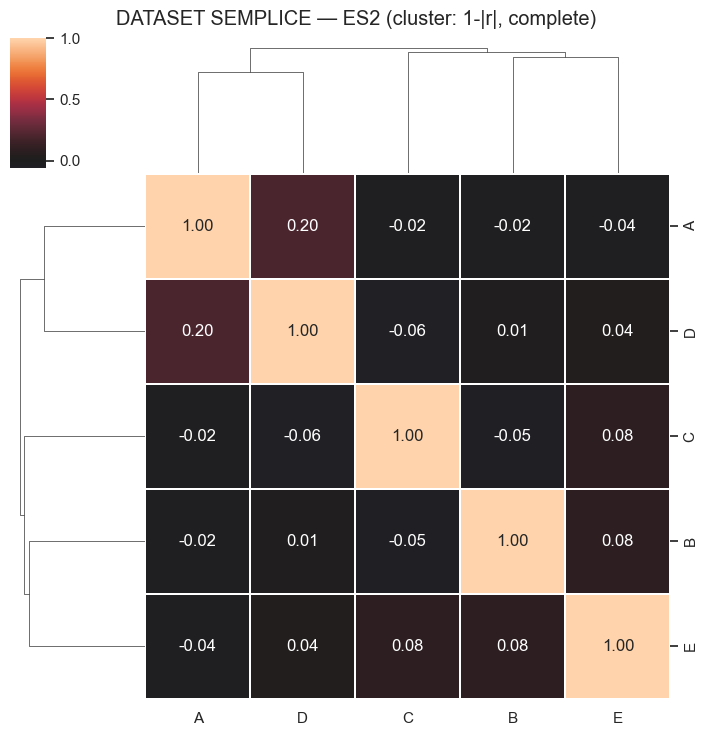

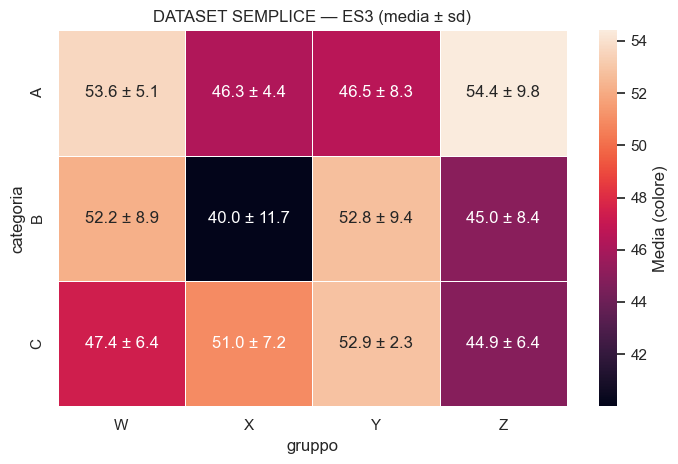

/opt/miniconda3/envs/ds/lib/python3.11/site-packages/seaborn/matrix.py:202: RuntimeWarning: All-NaN slice encountered
  vmin = np.nanmin(calc_data)
/opt/miniconda3/envs/ds/lib/python3.11/site-packages/seaborn/matrix.py:207: RuntimeWarning: All-NaN slice encountered
  vmax = np.nanmax(calc_data)


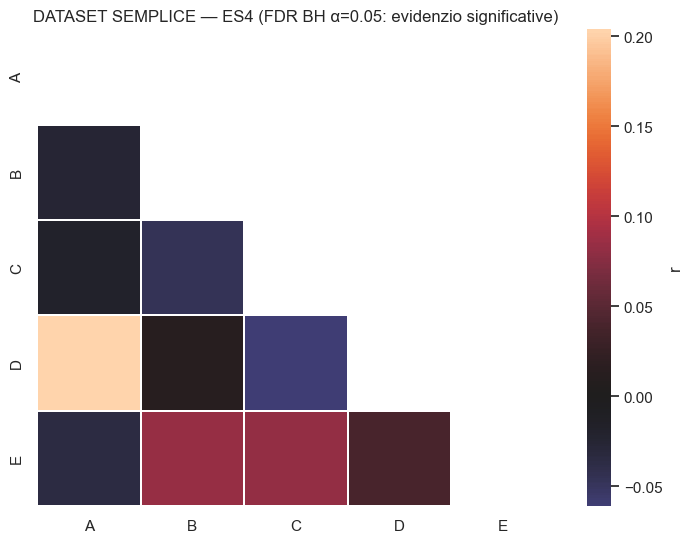

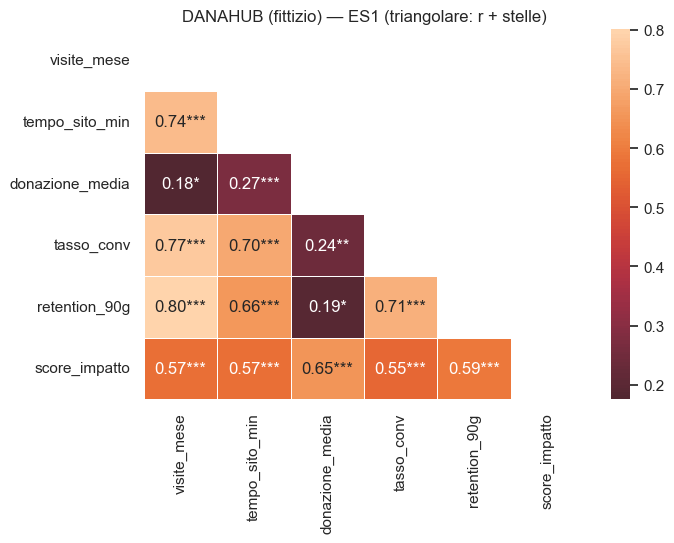

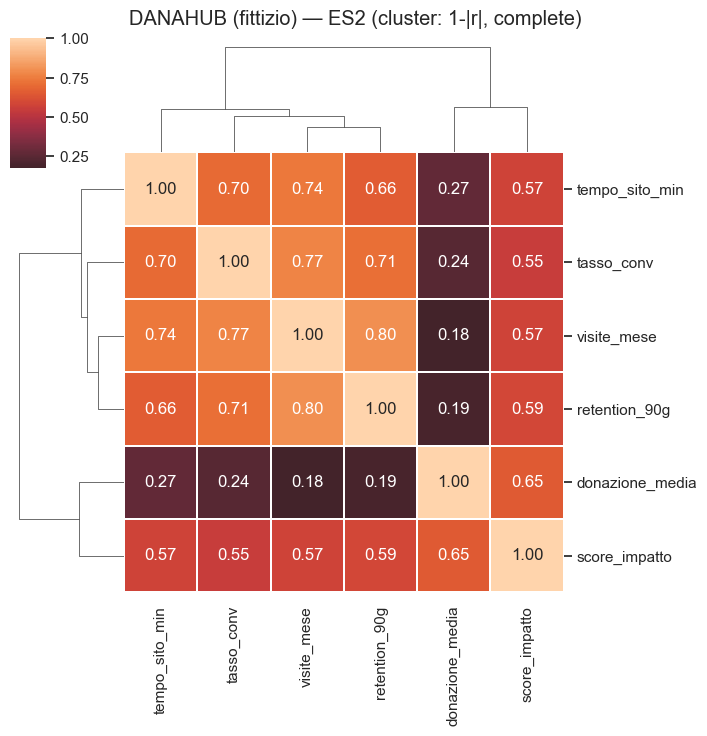

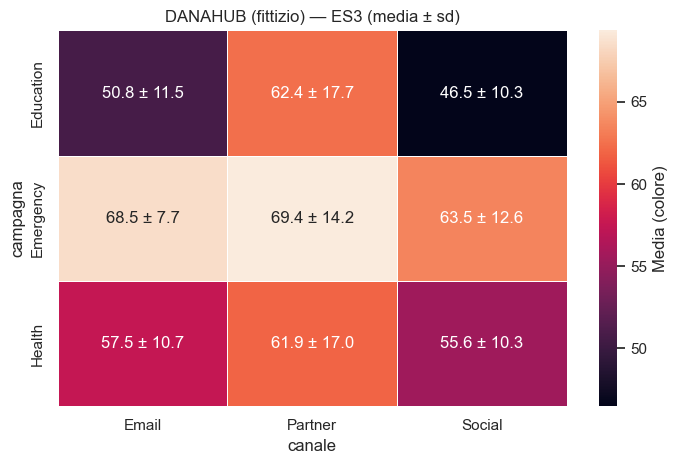

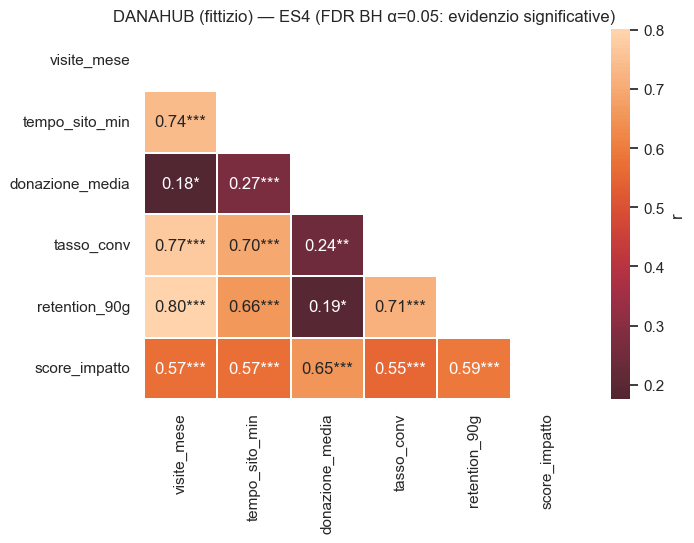

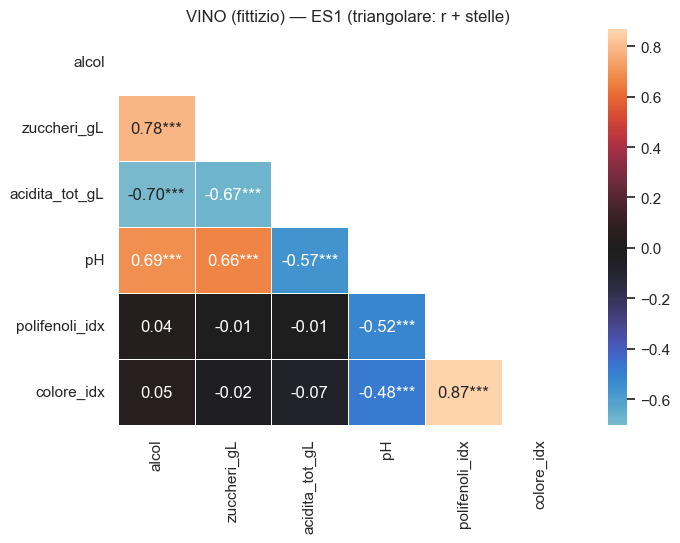

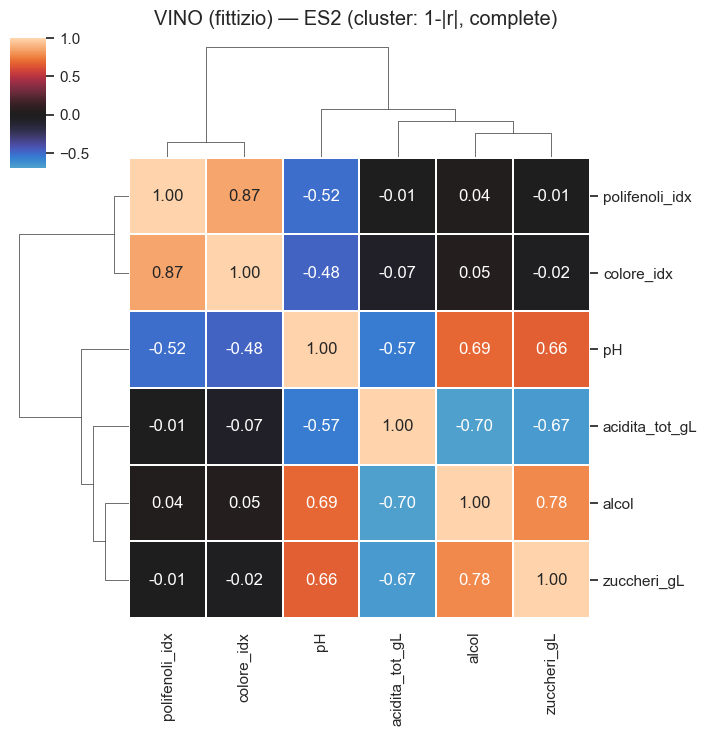

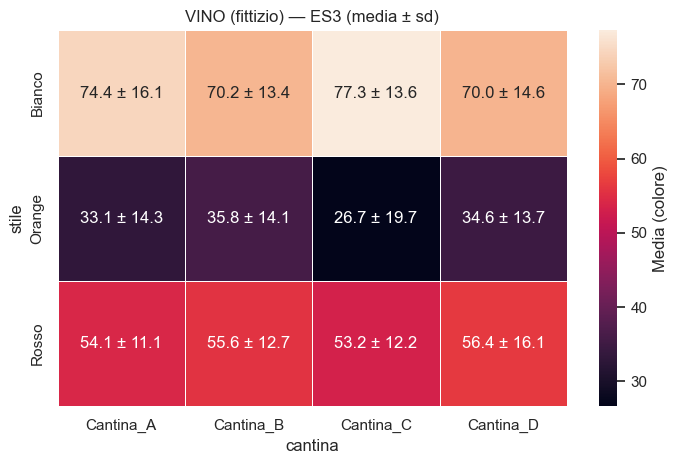

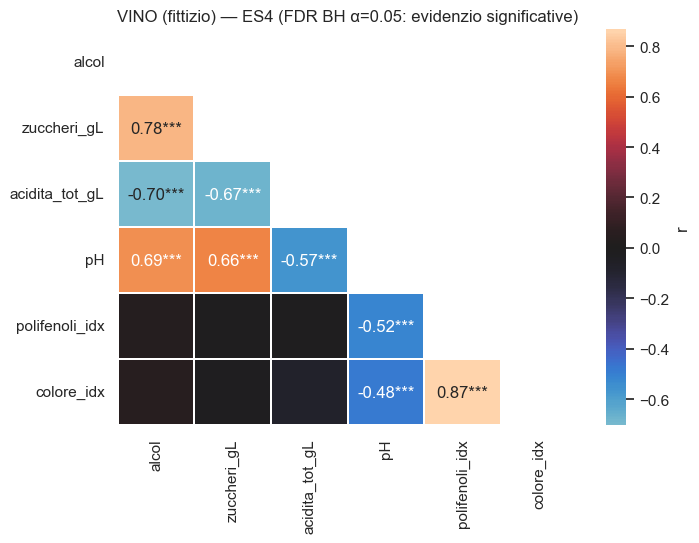

In [6]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from scipy.cluster.hierarchy import linkage
from scipy.spatial.distance import squareform

sns.set_theme(style="white")


# =========================================================
# Helpers (mini e leggibili)
# =========================================================
def corr_pvals(df_num: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Pearson r + matrice p-value (ciclo chiaro, senza magie)."""
    cols = df_num.columns
    n = len(cols)
    corr = pd.DataFrame(np.eye(n), index=cols, columns=cols, dtype=float)
    pval = pd.DataFrame(np.full((n, n), np.nan), index=cols, columns=cols, dtype=float)

    for i in range(n):
        for j in range(i + 1, n):
            r, p = stats.pearsonr(df_num.iloc[:, i], df_num.iloc[:, j])
            corr.iat[i, j] = corr.iat[j, i] = r
            pval.iat[i, j] = pval.iat[j, i] = p
    return corr, pval


def stars(p: float) -> str:
    if np.isnan(p): return ""
    if p <= 0.001: return "***"
    if p <= 0.01:  return "**"
    if p <= 0.05:  return "*"
    return ""


def fdr_bh(flat_p: np.ndarray, alpha: float = 0.05) -> tuple[np.ndarray, np.ndarray]:
    """FDR Benjamini–Hochberg: statsmodels se c’è, altrimenti fallback manuale."""
    flat_p = np.asarray(flat_p, dtype=float)

    try:
        from statsmodels.stats.multitest import multipletests
        rej, p_corr, *_ = multipletests(flat_p, alpha=alpha, method="fdr_bh")
        return rej.astype(bool), p_corr.astype(float)
    except Exception:
        p = flat_p.copy()
        m = p.size
        order = np.argsort(p)
        p_sorted = p[order]
        ranks = np.arange(1, m + 1)

        p_adj_sorted = p_sorted * m / ranks
        p_adj_sorted = np.minimum.accumulate(p_adj_sorted[::-1])[::-1]
        p_adj_sorted = np.clip(p_adj_sorted, 0, 1)

        rej_sorted = p_sorted <= (alpha * ranks / m)

        p_adj = np.empty_like(p_adj_sorted)
        rej = np.empty_like(rej_sorted, dtype=bool)
        p_adj[order] = p_adj_sorted
        rej[order] = rej_sorted
        return rej, p_adj


# =========================================================
# ESERCIZI 1–4 (versione essenziale)
# =========================================================
def es1(df_num: pd.DataFrame, title: str):
    """Triangolare con r + stelle."""
    corr, pvals = corr_pvals(df_num)
    mask = np.triu(np.ones_like(corr.values, dtype=bool))  # nascondo sopra+diag

    annot = np.empty_like(corr.values, dtype=object)
    for i in range(corr.shape[0]):
        for j in range(corr.shape[1]):
            annot[i, j] = f"{corr.values[i, j]:.2f}{stars(pvals.values[i, j])}"

    plt.figure(figsize=(7.2, 5.6))
    sns.heatmap(corr, mask=mask, annot=annot, fmt="", center=0, linewidths=0.5)
    plt.title(f"{title} — ES1 (triangolare: r + stelle)")
    plt.tight_layout()
    plt.show()


def es2(df_num: pd.DataFrame, title: str):
    """Clustered heatmap (metrica didattica: 1-|r|, linkage=complete)."""
    corr, _ = corr_pvals(df_num)

    dist = 1 - np.abs(corr.values)      # correlazioni forti (anche negative) => vicine
    np.fill_diagonal(dist, 0.0)
    Z = linkage(squareform(dist, checks=False), method="complete")

    g = sns.clustermap(
        corr,
        row_linkage=Z, col_linkage=Z,
        center=0,
        annot=True, fmt=".2f",
        linewidths=0.3,
        figsize=(7.2, 7.2),
    )
    g.fig.suptitle(f"{title} — ES2 (cluster: 1-|r|, complete)", y=1.02)
    plt.show()


def es3(long_df: pd.DataFrame, idx: str, cols: str, val: str, title: str):
    """Heatmap di medie + annotazione media ± sd."""
    pivot = long_df.pivot_table(values=val, index=idx, columns=cols, aggfunc=["mean", "std"])
    mean_mat = pivot["mean"]
    std_mat  = pivot["std"]

    annot = np.empty(mean_mat.shape, dtype=object)
    for i in range(mean_mat.shape[0]):
        for j in range(mean_mat.shape[1]):
            annot[i, j] = f"{mean_mat.values[i, j]:.1f} ± {std_mat.values[i, j]:.1f}"

    plt.figure(figsize=(7.2, 4.8))
    sns.heatmap(mean_mat, annot=annot, fmt="", linewidths=0.5, cbar_kws={"label": "Media (colore)"})
    plt.title(f"{title} — ES3 (media ± sd)")
    plt.tight_layout()
    plt.show()


def es4(df_num: pd.DataFrame, title: str, alpha: float = 0.05):
    """
    Correzione multipla (FDR BH).
    Visual: base triangolare + overlay SOLO celle significative (bordo più spesso).
    """
    corr, pvals = corr_pvals(df_num)
    n = corr.shape[0]
    mask_upper = np.triu(np.ones_like(corr.values, dtype=bool))

    tri_i, tri_j = np.tril_indices(n, k=-1)   # solo coppie uniche
    flat_p = pvals.values[tri_i, tri_j]

    rej, p_adj = fdr_bh(flat_p, alpha=alpha)

    sig = np.zeros((n, n), dtype=bool)
    sig[tri_i, tri_j] = rej
    sig[tri_j, tri_i] = rej

    p_adj_mat = np.full((n, n), np.nan, dtype=float)
    p_adj_mat[tri_i, tri_j] = p_adj
    p_adj_mat[tri_j, tri_i] = p_adj

    annot_sig = np.empty_like(corr.values, dtype=object)
    for i in range(n):
        for j in range(n):
            if np.isnan(p_adj_mat[i, j]):
                annot_sig[i, j] = ""
            else:
                annot_sig[i, j] = f"{corr.values[i, j]:.2f}{stars(p_adj_mat[i, j])}"

    plt.figure(figsize=(7.2, 5.6))
    ax = sns.heatmap(corr, mask=mask_upper, annot=False, center=0, linewidths=0.5, cbar_kws={"label": "r"})
    mask_overlay = mask_upper | (~sig)  # nascondo tutto ciò che NON è significativo
    sns.heatmap(corr, mask=mask_overlay, annot=annot_sig, fmt="", center=0, linewidths=1.4, cbar=False, ax=ax)

    plt.title(f"{title} — ES4 (FDR BH α={alpha}: evidenzio significative)")
    plt.tight_layout()
    plt.show()


def run_all(title: str, df_num: pd.DataFrame, long_df: pd.DataFrame, idx: str, cols: str, val: str):
    es1(df_num, title)
    es2(df_num, title)
    es3(long_df, idx, cols, val, title)
    es4(df_num, title, alpha=0.05)


# =========================================================
# Dataset A: "Semplice" (stile slide, super didattico)
# =========================================================
def make_simple():
    np.random.seed(0)
    df_num = pd.DataFrame(np.random.randn(60, 5), columns=list("ABCDE"))

    rng = np.random.default_rng(0)
    long_df = pd.DataFrame({
        "categoria": np.repeat(["A", "B", "C"], 12),
        "gruppo": np.tile(["X", "Y", "Z", "W"], 9),
        "valore": rng.normal(loc=50, scale=10, size=36),
    })
    return df_num, long_df


# =========================================================
# Dataset B: DanaHub (fittizio, ma “realistico” per il dominio)
# =========================================================
def make_danahub():
    rng = np.random.default_rng(1)
    n = 160

    engagement = rng.normal(size=n)   # “coinvolgimento”
    capacity   = rng.normal(size=n)   # “capacità di donazione”
    noise = lambda s=0.6: rng.normal(scale=s, size=n)

    df_num = pd.DataFrame({
        "visite_mese":     10 + 5*engagement + noise(2.0),
        "tempo_sito_min":  3.0 + 1.1*engagement + noise(0.6),
        "donazione_media": 35 + 16*capacity + 5*engagement + noise(7.0),
        "tasso_conv":      0.07 + 0.03*engagement + noise(0.02),
        "retention_90g":   0.22 + 0.08*engagement + noise(0.04),
        "score_impatto":   50 + 9*engagement + 7*capacity + noise(6.0),
    })
    df_num["tasso_conv"] = df_num["tasso_conv"].clip(0.0, 0.6)
    df_num["retention_90g"] = df_num["retention_90g"].clip(0.0, 1.0)

    # categoriale: campagna × canale → donazione singola
    rng = np.random.default_rng(2)
    long_df = pd.DataFrame({
        "campagna": rng.choice(["Education", "Health", "Emergency"], size=240, p=[0.45, 0.35, 0.20]),
        "canale":   rng.choice(["Email", "Social", "Partner"], size=240, p=[0.40, 0.45, 0.15]),
    })
    base = long_df["campagna"].map({"Education": 45, "Health": 55, "Emergency": 65}).astype(float)
    uplift = long_df["canale"].map({"Email": 6, "Social": 0, "Partner": 10}).astype(float)
    long_df["donazione"] = (base + uplift + rng.normal(0, 12, size=240)).clip(5, None)

    return df_num, long_df


# =========================================================
# Dataset C: Vino (fittizio, stile “chimica/struttura”)
# =========================================================
def make_wine():
    rng = np.random.default_rng(3)
    n = 150

    maturita = rng.normal(size=n)  # alcol/zuccheri/rotondità
    estraz   = rng.normal(size=n)  # polifenoli/colore/struttura
    noise = lambda s=0.6: rng.normal(scale=s, size=n)

    df_num = pd.DataFrame({
        "alcol":           12.0 + 0.8*maturita + noise(0.4),
        "zuccheri_gL":     2.0 + 1.0*maturita + noise(0.7),
        "acidita_tot_gL":  6.0 - 0.6*maturita + noise(0.5),
        "pH":              3.25 + 0.10*maturita - 0.08*estraz + noise(0.05),
        "polifenoli_idx":  50 + 16*estraz + noise(6.0),
        "colore_idx":      6 + 2.6*estraz + noise(1.0),
    })

    # categoriale: stile × cantina → solfiti totali (didattico)
    rng = np.random.default_rng(4)
    long_df = pd.DataFrame({
        "stile":   rng.choice(["Bianco", "Rosso", "Orange"], size=240, p=[0.45, 0.40, 0.15]),
        "cantina": rng.choice(["Cantina_A", "Cantina_B", "Cantina_C", "Cantina_D"], size=240),
    })
    base = long_df["stile"].map({"Bianco": 75, "Rosso": 55, "Orange": 35}).astype(float)
    long_df["solfiti_tot_mgL"] = (base + rng.normal(0, 14, size=240)).clip(5, None)

    return df_num, long_df


# =========================================================
# MAIN
# =========================================================
if __name__ == "__main__":
    df_s, long_s = make_simple()
    run_all("DATASET SEMPLICE", df_s, long_s, "categoria", "gruppo", "valore")

    df_d, long_d = make_danahub()
    run_all("DANAHUB (fittizio)", df_d, long_d, "campagna", "canale", "donazione")

    df_w, long_w = make_wine()
    run_all("VINO (fittizio)", df_w, long_w, "stile", "cantina", "solfiti_tot_mgL")